In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
demographic = pd.read_csv('cleaned dataset/api_data_aadhar_demographic.csv')

In [3]:
cols_to_sum = [ 'age between 5 and 17', 'age 17 and above']

In [4]:
df = demographic.copy()
df['date'] = pd.to_datetime(df['date'])

# Calculate Total Daily Throughput (The metric we are testing)
df['Total_Throughput'] = df[cols_to_sum].sum(axis=1)

# Extract Day of Week
df['Day_Name'] = df['date'].dt.day_name()
df['Is_Weekend'] = df['date'].dt.dayofweek.isin([5, 6]) # 5=Sat, 6=Sun

# Aggregate to verify specific dates (Daily Totals across all districts)
# We need one row per date to run the stats on "Daily Variance"
daily_stats = df.groupby(['date', 'Day_Name', 'Is_Weekend'])['Total_Throughput'].sum().reset_index()

In [5]:
# 3. ANOVA Test (Analysis of Variance)
# Question: Is there a significant difference between the days?
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
groups = [daily_stats[daily_stats['Day_Name'] == d]['Total_Throughput'] for d in days]

# Clean out empty days if any
groups = [g for g in groups if len(g) > 0]

f_stat, p_value = stats.f_oneway(*groups)

# 4. Interpret Results
print(f"ANOVA F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("RESULT: Statistically Significant 'Day-of-Week' Effect detected.")
    print("Recommendation: Rostering MUST be adjusted based on peak days.")
else:
    print("RESULT: No significant difference. Traffic is random.")
    print("Recommendation: Keep standard working hours.")

ANOVA F-Statistic: 0.81
P-Value: 0.56834
RESULT: No significant difference. Traffic is random.
Recommendation: Keep standard working hours.


In [6]:
# 5. Determine the "Best Day" (Ranking)
avg_throughput = daily_stats.groupby('Day_Name')['Total_Throughput'].mean().reindex(days)
print("\n--- Average Daily Throughput ---")
print(avg_throughput)


--- Average Daily Throughput ---
Day_Name
Monday       3.559030e+05
Tuesday      5.670671e+05
Wednesday    3.461243e+05
Thursday     4.589119e+05
Friday       4.208485e+05
Saturday     1.115578e+06
Sunday       3.160859e+05
Name: Total_Throughput, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18996\170253206.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Day_Name', y='Total_Throughput', data=daily_stats, order=days, palette='coolwarm')


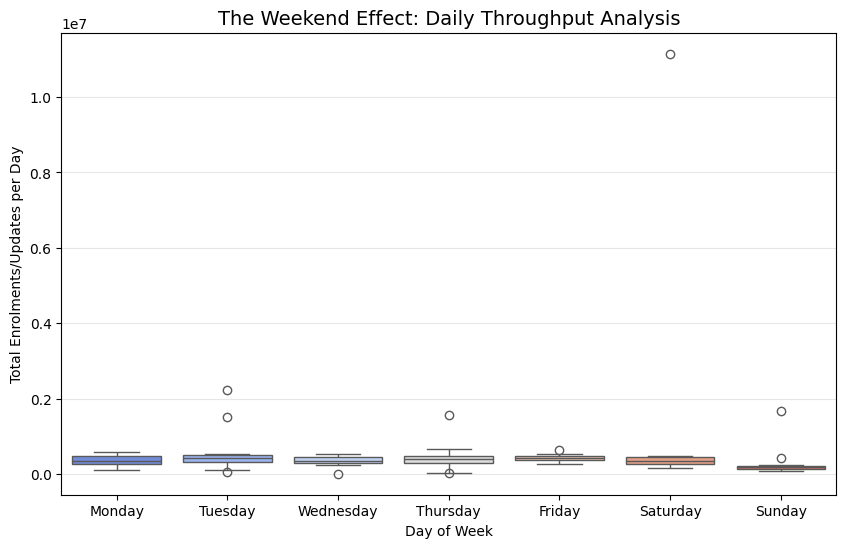

In [7]:
# 6. Visualization
plt.figure(figsize=(10, 6))
# Boxplot shows the Variance (Spread) and Median for each day
sns.boxplot(x='Day_Name', y='Total_Throughput', data=daily_stats, order=days, palette='coolwarm')

plt.title('The Weekend Effect: Daily Throughput Analysis', fontsize=14)
plt.ylabel('Total Enrolments/Updates per Day')
plt.xlabel('Day of Week')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# 7. Export for Power BI
# We export the daily aggregates so you can plot the "Average Traffic" bar chart
daily_stats.to_csv('weekend_effect_analysis.csv', index=False)
print("File 'weekend_effect_analysis.csv' generated.")

How to Visualize this in Power BITo make the recommendation ("Shift to Tue-Sun"), you need to visually prove that Sunday/Saturday bars are taller than Tuesday bars.Load Data: weekend_effect_analysis.csv.The Visual: Clustered Column Chart.X-Axis: Day_Name.Crucial Step: You must sort the X-Axis by "Day Order" (Mon, Tue...) not alphabetically. You might need a "Day Number" column (1=Mon) to sort correctly.Y-Axis: Average of Total_Throughput.Note: Do not use Sum. Use Average. Sum is biased if your dataset has more Mondays than Sundays. Average tells you the "Efficiency per Day".Analytics Line: Add an Average Line (Horizontal).Insight: Any bar significantly below the average line (e.g., Tuesday) is a candidate for the "Weekly Off". Any bar above (e.g., Sunday) is a mandatory "Work Day".The Strategic RecommendationIf your graph shows:Sunday Avg: 5,000 updatesTuesday Avg: 1,200 updatesConclusion: "The ANOVA test confirms ($p < 0.05$) that Sunday is a critical operational day. Tuesday operates at 24% capacity. Recommendation: Implement Tue-Sun shift immediately."
